In [1]:
# Task 1: Understand the Business Problem

print("""
Task 1: Understand the Business Problem

What is the business about?
PayFlow Business Solutions is a B2B financial operations company that helps small and medium-sized businesses manage invoicing, payment collection, and accounts receivable. The company works with clients in industries such as retail, professional services, construction, healthcare, manufacturing, and technology.

What problem is the business trying to solve?
The business problem is that late invoice payments create serious cash-flow problems. When customers pay late, companies may struggle to pay suppliers, manage payroll, and plan future growth. PayFlow wants to identify invoices that are at high risk of being paid late before the due date passes, so that staff can prioritize follow-up actions and support customers earlier.

What decision can machine learning help the business make?
Machine learning can help PayFlow predict whether an invoice is likely to be paid late. A Decision Tree model can use customer history, invoice characteristics, payment behaviour, and service interaction variables to classify each invoice as likely late or likely on time.

What is the target variable in the dataset?
The target variable is Late_Payment. A value of Yes means the invoice is expected to be paid late and a value of No means the invoice is expected to be paid on time.

What are the input features?
The input features are Customer_Segment, Industry, Region, Invoice_Month, Invoice_Amount, Payment_Terms_Days, Customer_Tenure_Months, Prior_Late_Payments, Avg_Days_To_Pay, Days_Since_Last_Order, Dispute_Flag, Reminder_Count, Online_Portal_Use, Early_Payment_Discount_Offered, and Credit_Score_Band.

Why is this prediction useful for the business?
This prediction is useful because instead of treating every invoice the same way, PayFlow can focus earlier attention on invoices that are more likely to become late. This improves cash-flow planning, reduces manual collection workload, and helps businesses communicate with customers before payment issues become serious.
""")


Task 1: Understand the Business Problem

What is the business about?
PayFlow Business Solutions is a B2B financial operations company that helps small and medium-sized businesses manage invoicing, payment collection, and accounts receivable. The company works with clients in industries such as retail, professional services, construction, healthcare, manufacturing, and technology.

What problem is the business trying to solve?
The business problem is that late invoice payments create serious cash-flow problems. When customers pay late, companies may struggle to pay suppliers, manage payroll, and plan future growth. PayFlow wants to identify invoices that are at high risk of being paid late before the due date passes, so that staff can prioritize follow-up actions and support customers earlier.

What decision can machine learning help the business make?
Machine learning can help PayFlow predict whether an invoice is likely to be paid late. A Decision Tree model can use customer history,

In [2]:
# Task 2: Prepare the Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [5]:
# Load the dataset
df = pd.read_excel("C:\\Users\\nnish\\OneDrive\\Desktop\\Dataset\\payflow_invoice_late_payment_business_plan\\payflow_invoice_late_payment_dataset.xlsx")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [6]:
# Inspect the dataset
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
     Invoice_ID Customer_Segment             Industry            Region  \
0  INV-20260001   Small Business         Construction          Prairies   
1  INV-20260002   Small Business  Healthcare Services  British Columbia   
2  INV-20260003       Mid-Market               Retail          Prairies   
3  INV-20260004   Small Business               Retail  British Columbia   
4  INV-20260005       Mid-Market           Technology           Alberta   

  Invoice_Month  Invoice_Amount  Payment_Terms_Days  Customer_Tenure_Months  \
0           Aug         5851.94                  30                      28   
1           Aug         3224.65                  30                      34   
2           Dec        17946.67                  30                      12   
3           Sep         5131.03                  15                      25   
4           Aug        17553.63                  60                      14   

   Prior_Late_Payments  Avg_Days_To_Pay  Days_Since_Last_Or

In [7]:
# Check the number of rows and columns
print("\nShape:", df.shape)


Shape: (360, 17)


In [8]:
# Check data types
print("\nData Types:")
print(df.dtypes)



Data Types:
Invoice_ID                         object
Customer_Segment                   object
Industry                           object
Region                             object
Invoice_Month                      object
Invoice_Amount                    float64
Payment_Terms_Days                  int64
Customer_Tenure_Months              int64
Prior_Late_Payments                 int64
Avg_Days_To_Pay                     int64
Days_Since_Last_Order               int64
Dispute_Flag                       object
Reminder_Count                      int64
Online_Portal_Use                  object
Early_Payment_Discount_Offered     object
Credit_Score_Band                  object
Late_Payment                       object
dtype: object


In [9]:
# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())
print(f"Total Missing Values: {df.isnull().sum().sum()}")


Missing Values:
Invoice_ID                        0
Customer_Segment                  0
Industry                          0
Region                            0
Invoice_Month                     0
Invoice_Amount                    0
Payment_Terms_Days                0
Customer_Tenure_Months            0
Prior_Late_Payments               0
Avg_Days_To_Pay                   0
Days_Since_Last_Order             0
Dispute_Flag                      0
Reminder_Count                    0
Online_Portal_Use                 0
Early_Payment_Discount_Offered    0
Credit_Score_Band                 0
Late_Payment                      0
dtype: int64
Total Missing Values: 0


In [10]:
# Check duplicate rows
print(f"\nDuplicate Rows: {df.duplicated().sum()}")


Duplicate Rows: 0


In [11]:
# Clean the dataset
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
print(f"\nShape after removing duplicates: {df_clean.shape}")


Shape after removing duplicates: (360, 17)


In [12]:
# Fill missing numerical values with median
for col in df_clean.select_dtypes(include=['float64', 'int64']).columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill missing categorical values with mode
for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print(f"Total Missing Values after Cleaning: {df_clean.isnull().sum().sum()}")

Total Missing Values after Cleaning: 0


In [13]:
# Separate features and target variable
df_clean = df_clean.drop(columns=['Invoice_ID'])

X = df_clean.drop(columns=['Late_Payment'])
y = df_clean['Late_Payment']

print(f"\nFeatures Shape: {X.shape}")
print(f"Target Shape: {y.shape}")
print("\nTarget Value Counts:")
print(y.value_counts())


Features Shape: (360, 15)
Target Shape: (360,)

Target Value Counts:
Late_Payment
No     201
Yes    159
Name: count, dtype: int64


In [14]:
# Handle categorical variables
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"\nTarget Classes: {le_target.classes_}")
print("Encoded Values: 0 = No, 1 = Yes")

X_encoded = X.copy()
for col in X_encoded.select_dtypes(include='object').columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col])

print("\nEncoded Features Sample:")
print(X_encoded.head())


Target Classes: ['No' 'Yes']
Encoded Values: 0 = No, 1 = Yes

Encoded Features Sample:
   Customer_Segment  Industry  Region  Invoice_Month  Invoice_Amount  \
0                 2         0       4              1         5851.94   
1                 2         1       2              1         3224.65   
2                 1         4       4              2        17946.67   
3                 2         4       2             11         5131.03   
4                 1         5       0              1        17553.63   

   Payment_Terms_Days  Customer_Tenure_Months  Prior_Late_Payments  \
0                  30                      28                    1   
1                  30                      34                    2   
2                  30                      12                    2   
3                  15                      25                    5   
4                  60                      14                    0   

   Avg_Days_To_Pay  Days_Since_Last_Order  Dispute_Flag  R

In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nTraining Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")


Training Set Shape: (288, 15)
Testing Set Shape: (72, 15)


In [16]:
# Task 3: Train a Decision Tree Classification Model

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
# Train the Decision Tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
# Predictions
y_pred_train = dt.predict(X_train)
y_pred_test = dt.predict(X_test)

# Training and Testing Accuracy
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Training Accuracy: {round(train_acc, 4)}")
print(f"Testing Accuracy: {round(test_acc, 4)}")

Training Accuracy: 1.0
Testing Accuracy: 0.5556



Confusion Matrix:
[[22 18]
 [14 18]]


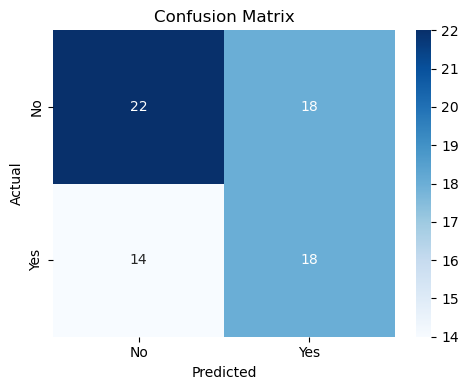

In [21]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'],
            yticklabels=['No', 'Yes'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_payflow.png', dpi=150)
plt.show()

In [22]:
# Evaluation Metrics
print(f"\nAccuracy : {round(accuracy_score(y_test, y_pred_test), 4)}")
print(f"Precision: {round(precision_score(y_test, y_pred_test), 4)}")
print(f"Recall   : {round(recall_score(y_test, y_pred_test), 4)}")
print(f"F1-Score : {round(f1_score(y_test, y_pred_test), 4)}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_test, target_names=['No', 'Yes']))


Accuracy : 0.5556
Precision: 0.5
Recall   : 0.5625
F1-Score : 0.5294

Classification Report:
              precision    recall  f1-score   support

          No       0.61      0.55      0.58        40
         Yes       0.50      0.56      0.53        32

    accuracy                           0.56        72
   macro avg       0.56      0.56      0.55        72
weighted avg       0.56      0.56      0.56        72



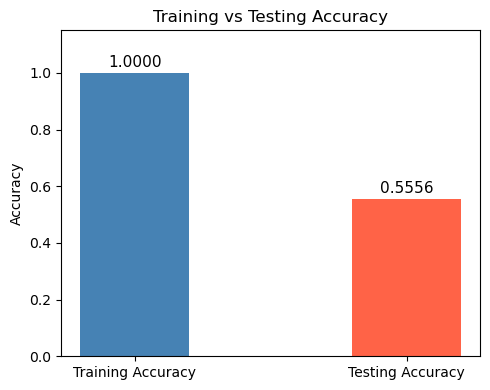

In [23]:
# Training vs Testing Accuracy Chart
plt.figure(figsize=(5, 4))
bars = plt.bar(['Training Accuracy', 'Testing Accuracy'],
               [train_acc, test_acc],
               color=['steelblue', 'tomato'], width=0.4)
plt.ylim(0, 1.15)
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{bar.get_height():.4f}', ha='center', fontsize=11)
plt.title('Training vs Testing Accuracy')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.savefig('train_vs_test_payflow.png', dpi=150)
plt.show()

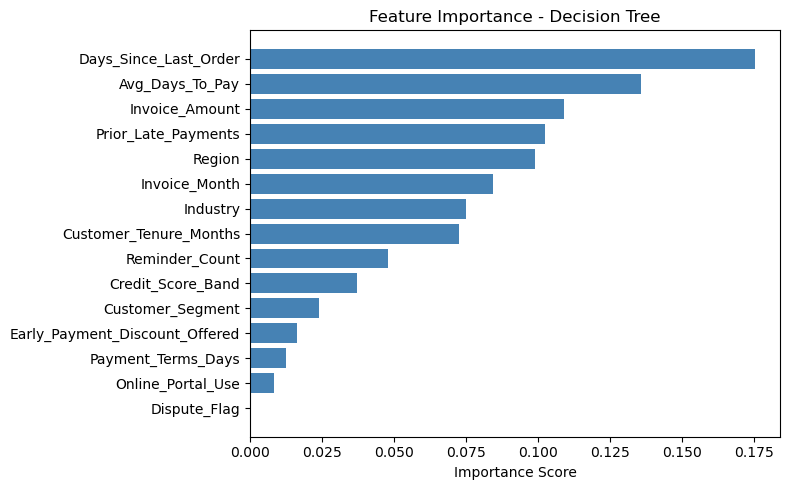


Feature Importances:
                           Feature  Importance
9            Days_Since_Last_Order    0.175359
8                  Avg_Days_To_Pay    0.135814
4                   Invoice_Amount    0.109034
7              Prior_Late_Payments    0.102510
2                           Region    0.098850
3                    Invoice_Month    0.084467
1                         Industry    0.074889
6           Customer_Tenure_Months    0.072720
11                  Reminder_Count    0.048040
14               Credit_Score_Band    0.037203
0                 Customer_Segment    0.023945
13  Early_Payment_Discount_Offered    0.016433
5               Payment_Terms_Days    0.012520
12               Online_Portal_Use    0.008216
10                    Dispute_Flag    0.000000


In [24]:
# Feature Importance
importances = dt.feature_importances_
feat_df = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance - Decision Tree')
plt.tight_layout()
plt.savefig('feature_importance_payflow.png', dpi=150)
plt.show()

print("\nFeature Importances:")
print(feat_df)

In [25]:
# Overfitting Check
diff = train_acc - test_acc
print(f"\nAccuracy Gap (Train - Test): {round(diff, 4)}")
if diff > 0.10:
    print("Large gap detected. The model is likely overfitting.")
else:
    print("Small gap. The model generalizes reasonably well.")


Accuracy Gap (Train - Test): 0.4444
Large gap detected. The model is likely overfitting.
